In [14]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint

from langchain_core.messages import HumanMessage,RemoveMessage

In [15]:
load_dotenv()

True

In [16]:
llm=HuggingFaceEndpoint(
    repo_id="openai/gpt-oss-120b",
    task="text-generation"
)

model=ChatHuggingFace(llm=llm)

In [17]:
class ChatState(MessagesState):
    summary:str

In [18]:
def chat_node(state:ChatState):
    messages=[]
    if state['summary']:
        messages.append({
            "role":"System",
            "content":f'Conversation summary:\n{state['summary']}'
        })
    
    messages.extend(state['messages'])
    print(messages)
    response=model.invoke(messages)
    return {
        'messages':[response]
    }

In [19]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [20]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [21]:
builder = StateGraph(ChatState)

builder.add_node("MODEL", chat_node)
builder.add_node("SUMMARY", summarize_conversation)

builder.add_edge(START, "MODEL")

builder.add_conditional_edges(
    "MODEL",
    should_summarize,
    {
        True: "SUMMARY",
        False: "__end__",
    }
)

builder.add_edge("SUMMARY", "__end__")



In [22]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

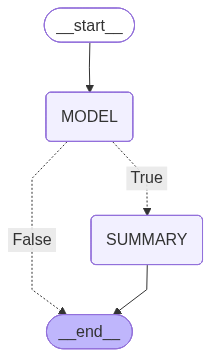

In [23]:
graph

In [24]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [25]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [26]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='039fe58e-e863-416c-8126-ade239839249')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Sure! Quantum physics (or quantum mechanics) is the branch of physics that descr


In [27]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='039fe58e-e863-416c-8126-ade239839249'), AIMessage(content='Sure! Quantum physics (or quantum mechanics) is the branch of physics that describes the behavior of matter and energy at the smallest scales—typically atomic, molecular, and sub‑atomic levels. It’s a remarkably successful theory, underpinning everything from lasers and transistors to MRI scanners and modern cryptography. Below is a high‑level roadmap that you can use to dive deeper, followed by brief explanations of the core ideas and some “next‑step” resources.\n\n---\n\n## 1️⃣ Quick‑Start Overview (5‑Minute Read)\n\n| Concept | What It Says | Why It Matters |\n|---------|--------------|----------------|\n| **Wave‑Particle Duality** | Particles (e.g., electrons, photons) exhibit both wave‑like and particle‑like properties. | Explains diffraction of electrons, the photo‑electric effect, and why “particles” can interfere. |\n| **Quantizatio

In [28]:
run_turn('What are some of Einstien"s fampus work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='039fe58e-e863-416c-8126-ade239839249'), AIMessage(content='Sure! Quantum physics (or quantum mechanics) is the branch of physics that describes the behavior of matter and energy at the smallest scales—typically atomic, molecular, and sub‑atomic levels. It’s a remarkably successful theory, underpinning everything from lasers and transistors to MRI scanners and modern cryptography. Below is a high‑level roadmap that you can use to dive deeper, followed by brief explanations of the core ideas and some “next‑step” resources.\n\n---\n\n## 1️⃣ Quick‑Start Overview (5‑Minute Read)\n\n| Concept | What It Says | Why It Matters |\n|---------|--------------|----------------|\n| **Wave‑Particle Duality** | Particles (e.g., electrons, photons) exhibit both wave‑like and particle‑like properties. | Explains diffraction of electrons, the photo‑electric effect, and why “particles” can interfere. |\n| **Quantizatio

In [29]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='039fe58e-e863-416c-8126-ade239839249'), AIMessage(content='Sure! Quantum physics (or quantum mechanics) is the branch of physics that describes the behavior of matter and energy at the smallest scales—typically atomic, molecular, and sub‑atomic levels. It’s a remarkably successful theory, underpinning everything from lasers and transistors to MRI scanners and modern cryptography. Below is a high‑level roadmap that you can use to dive deeper, followed by brief explanations of the core ideas and some “next‑step” resources.\n\n---\n\n## 1️⃣ Quick‑Start Overview (5‑Minute Read)\n\n| Concept | What It Says | Why It Matters |\n|---------|--------------|----------------|\n| **Wave‑Particle Duality** | Particles (e.g., electrons, photons) exhibit both wave‑like and particle‑like properties. | Explains diffraction of electrons, the photo‑electric effect, and why “particles” can interfere. |\n| **Quantizatio